In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

In [29]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
data = tf.keras.datasets.mnist.load_data()
type(data)

len(data[0])

(X_train, y_train), (X_test, y_test) = data

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  13  25 100
  122   7   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0  33 151 208 252 252
  252 146   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0  40 152 244 252 253 224 211
  252 232  40   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  15 152 239 252 252 252 21

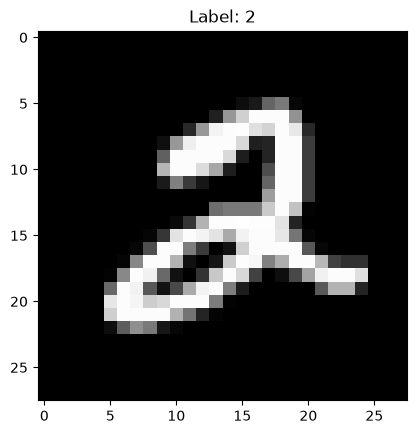

In [21]:
data[0]
data[1]

len(data[0][0])
len(data[0][1])

print(data[0][0][5])

plt.imshow(X_train[5], cmap = 'grey')
plt.title(f"Label: {y_train[5]}")
plt.show()

In [22]:
X_train[5].shape
len(X_train[0].flatten())

784

In [23]:
from tensorflow.keras import layers

DL_model = tf.keras.models.Sequential([
    # input layer
    layers.Flatten(input_shape = (28, 28)), # squishes the 2D array into a 1D array
    layers.Dense(128, activation= 'relu'),
    layers.Dense(10, activation ='softmax') # loudest voice

])

DL_model.compile(optimizer= 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

DL_model.summary()

c:\Users\Nurfatini Nasuha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
DL_model.fit(X_train, y_train, epochs = 3, batch_size = 10)

test_loss, test_acc = DL_model.evaluate(X_test, y_test)

Epoch 1/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - accuracy: 0.8540 - loss: 1.9161
Epoch 2/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9046 - loss: 0.3971
Epoch 3/3
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.9188 - loss: 0.3480
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9148 - loss: 0.3461


In [25]:
print(f"Test accuracy of the model is: {test_acc*100:.2f}% ")

Test accuracy of the model is: 91.48% 


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


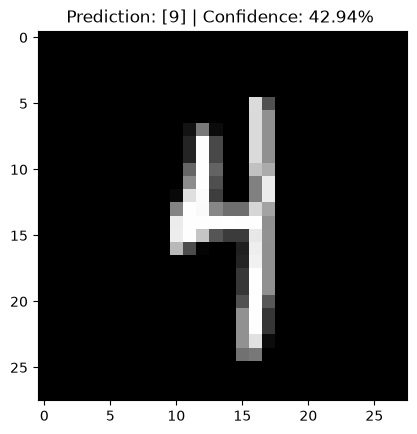

In [37]:
img = X_test[65]

prediction_img = DL_model.predict(img.reshape(1, 28, 28))
                                  
prediction_label = np.argmax(prediction_img, axis = 1)
confidence = prediction_img[0][prediction_label].item()


plt.imshow(img, cmap= 'gray')
plt.title(f"Prediction: {prediction_label} | Confidence: {float(confidence)*100:.2f}% ")
plt.show()

In [38]:
prediction_img[0][prediction_label]

array([0.4293553], dtype=float32)

In [39]:
img = X_test[10]

img.reshape(1, 28, 28).shape

# np.expand_dims(img, 0).shape

(1, 28, 28)

In [41]:
predictions = DL_model.predict(X_test)

y_pred = np.argmax(predictions, axis=1)

report = classification_report(y_pred, y_test)

print(report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       967
           1       0.97      0.98      0.98      1120
           2       0.87      0.96      0.92       935
           3       0.94      0.85      0.89      1112
           4       0.87      0.98      0.92       874
           5       0.87      0.96      0.91       808
           6       0.88      0.98      0.93       862
           7       0.89      0.99      0.94       927
           8       0.96      0.69      0.80      1351
           9       0.92      0.89      0.91      1044

    accuracy                           0.91     10000
   macro avg       0.91      0.93      0.92     10000
weighted avg       0.92      0.91      0.91     10000



In [47]:
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dropout, Dense
from tensorflow.keras.models import Sequential


# tensorflow model will take the shape as (height, width, channels) --- multiple channels too
def idrees_cnn(input_shape = (28, 28, 1), num_classes = 10):
    model = Sequential()

    # part 1: Edge and basic shape detection
    model.add(Conv2D(filters = 32, input_shape = input_shape, kernel_size=(3,3), activation= 'relu'))
    model.add(MaxPool2D(pool_size = (2,2)))

    # part 2 ===> detect more features
    model.add(Conv2D(64, kernel_size=(3,3), activation= 'relu'))
    model.add(MaxPool2D(pool_size = (2,2)))
    
    # conversion to 1D === convolution part is done. now we need the training power. brain cells
    model.add(Flatten())

    # we add dropouts, to reduce overfitting
    model.add(Dropout(0.5)) # turns off 50% of the neurons in the network will be turned off randomly

    # add a dense layers --- fully connected --
    model.add(Dense(128, activation= 'relu'))

    # output layer
    model.add(Dense(units = num_classes, activation= 'softmax'))

    model.compile(optimizer= 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
    
    return model

In [48]:
model = idrees_cnn()

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# data 
data = tf.keras.datasets.mnist.load_data()

# already train test splitted data
(X_train, y_train), (X_test, y_test) = data

X_train.shape

(60000, 28, 28)

In [50]:
# data preprocessing

# why do we change from 2D to 3D -- tensorflow models genrally take this shape for 3D arrays - images
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

# we perform scaling operations as well to improve model performance
# # if you have big values in data --- gradient decent faces issues -- explosive gradients
# X_train = X_train/255
# X_test = X_test/255

In [51]:
# training

history = model.fit(X_train, y_train,
          epochs = 5, 
          batch_size = 10,
          validation_split = 0.2 # you can get the training and testing accuracy
          )

Epoch 1/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 75s 15ms/step - accuracy: 0.9151 - loss: 0.3964 - val_accuracy: 0.9747 - val_loss: 0.0811
Epoch 2/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 80s 17ms/step - accuracy: 0.9592 - loss: 0.1369 - val_accuracy: 0.9818 - val_loss: 0.0624
Epoch 3/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 70s 15ms/step - accuracy: 0.9687 - loss: 0.1086 - val_accuracy: 0.9833 - val_loss: 0.0628
Epoch 4/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 72s 15ms/step - accuracy: 0.9725 - loss: 0.0972 - val_accuracy: 0.9804 - val_loss: 0.0629
Epoch 5/5
4800/4800 ━━━━━━━━━━━━━━━━━━━━ 76s 16ms/step - accuracy: 0.9744 - loss: 0.0914 - val_accuracy: 0.9816 - val_loss: 0.0671


In [52]:
# evaluation
test_loss, test_accuracy = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9846 - loss: 0.0598


In [53]:
# save the model
model.summary()

model.save('fatini_digit_recog_model.keras')

# .keras

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

In [54]:
import numpy as np

from PIL import Image, ImageOps

import tensorflow as tf

In [55]:
# load the model

model = tf.keras.models.load_model('fatini_digit_recog_model.keras')

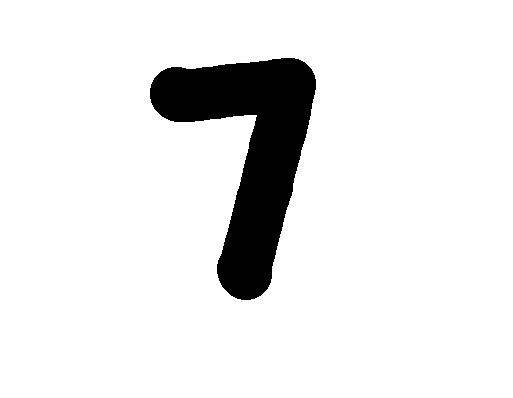

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   7   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   6  63  55  82 124 151 185 217 157   6
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 131 255 255 255 255 255 255 255 255  55
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 205 255 255 255 255 255 255 255 254  55
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 153 255 255 255 255 248 253 255 239  25
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  18 129 143 106  65  63 244 25

(1, 28, 28, 1)

In [58]:
path = 'test_2.jpg'
path = 'test_1.png'

img = Image.open(path)
display(img)

# data preprocessing
img.size
# size is (513, 398)
img = img.resize((28,28))
display(img)

# greyscale the image
img = img.convert('L') # change the 4 channel image into grey scale
display(img)

# will turn white into black
img = ImageOps.invert(img) # ivnerts the image

# convert into a numpy array
img_array = np.array(img)
img_array.shape
print(img_array)

# reshape
img_array = img_array.reshape(1, 28, 28, 1)
img_array.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


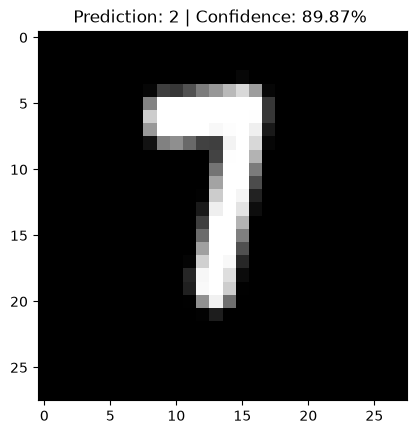

In [60]:
prediction_img = model.predict(img_array)
                                  
prediction_label = np.argmax(prediction_img, axis = 1)[0]
confidence = prediction_img[0][prediction_label]


plt.imshow(img, cmap= 'gray')
plt.title(f"Prediction: {prediction_label} | Confidence: {float(confidence)*100:.2f}% ")
plt.show()

In [65]:
import tensorflow as tf
import numpy as np
from PIL import Image, ImageOps

model = tf.keras.models.load_model('fatini_digit_recog_model.keras')

def predict_custom_image(path):
    # 2. Open image with PIL
    img = Image.open(path)
    
      # 4. Resize to 28x28
    img = img.resize((28, 28))

    # 3. Preprocess: Convert to Grayscale ('L' mode)
    img = img.convert('L')
    
    # 5. Invert Colors (Optional)
    # MNIST data is white ink on black background. 
    # If you drew black ink on white paper, you MUST invert it.
    img = ImageOps.invert(img)
    
    # 6. Convert to Numpy Array and Normalize
    img_array = np.array(img)
    
    img_array = img_array/ 255.0 # we did not train our model
    
    # 7. Reshape to match (Batch, Width, Height, Channel)
    # Shape becomes (1, 28, 28, 1)
    img_array = img_array.reshape(1, 28, 28, 1)
    
    # 8. Inference
    prediction = model.predict(img_array)

    result = np.argmax(prediction, axis = 1)[0]
    
    confidence = np.max(prediction)
    
    print(f"Prediction: {result} (Confidence: {confidence*100:.2f}%)")

    plt.imshow(img, cmap= 'gray')
    plt.title(f"Prediction: {result} | Confidence: {float(confidence)*100:.2f}% ")
    plt.show()

    return result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
Prediction: 1 (Confidence: 15.84%)


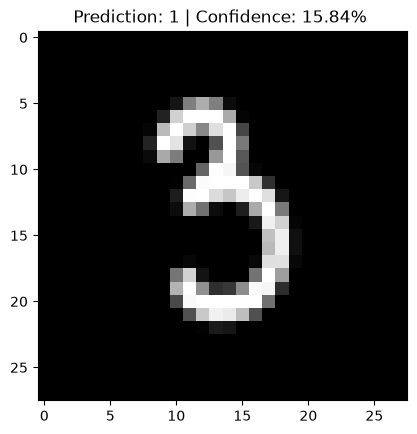

np.int64(1)

In [66]:
path = 'test_2.jpg'
path = 'test_1.png'
path = 'test_3.png'
path = 'test_4.png'
path = 'test_5.png'


predict_custom_image(path = path)